In [2]:
!pip install transformers datasets scikit-learn torch

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

In [4]:
df = pd.read_csv("/content/cleaned_customer_support_english.csv")
df.head(5)

,cleaned_text,type,priority,queue
0,account disruption dear customer support teamn...,Incident,high,Technical Support
1,query smart home system integration features d...,Request,medium,Returns and Exchanges
2,inquiry regarding invoice details dear custome...,Request,low,Billing and Payments
3,question marketing agency software compatibili...,Problem,medium,Sales and Pre-Sales
4,feature query dear customer supportnni hope me...,Request,high,Technical Support


In [26]:
df['type'].value_counts()

,count
type,
Incident,4717
Request,3320
Problem,2413
Change,1226


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11676 entries, 0 to 11675
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cleaned_text  11676 non-null  object
 1   type          11676 non-null  object
 2   priority      11676 non-null  object
 3   queue         11676 non-null  object
 4   label         11676 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 456.2+ KB


In [28]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['type'])

In [29]:
df.head(5)

,cleaned_text,type,priority,queue,label
0,account disruption dear customer support teamn...,Incident,high,Technical Support,1
1,query smart home system integration features d...,Request,medium,Returns and Exchanges,3
2,inquiry regarding invoice details dear custome...,Request,low,Billing and Payments,3
3,question marketing agency software compatibili...,Problem,medium,Sales and Pre-Sales,2
4,feature query dear customer supportnni hope me...,Request,high,Technical Support,3


In [30]:
print("Encoded Labels:\n", df[['type','label']].drop_duplicates())

Encoded Labels:
         type  label
0   Incident      1
1    Request      3
3    Problem      2
15    Change      0


In [31]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['cleaned_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)


In [32]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

class TicketDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

train_dataset = TicketDataset(train_encodings, train_labels)
test_dataset = TicketDataset(test_encodings, test_labels)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [33]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(df['label'].unique()))

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
!pip install -U transformers

In [44]:
training_args = TrainingArguments(
    output_dir='./results',
    do_eval=True,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    report_to=None   # disables wandb
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-3876680192.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [45]:
trainer.train()
trainer.evaluate()

Step,Training Loss
500,0.268600
1000,0.247100
1500,0.158300


{'eval_loss': 0.513355016708374,
 'eval_runtime': 13.87,
 'eval_samples_per_second': 168.421,
 'eval_steps_per_second': 10.526,
 'epoch': 3.0}

In [50]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.8595890410958904

Classification Report:
               precision    recall  f1-score   support

      Change       1.00      0.99      0.99       245
    Incident       0.82      0.84      0.83       944
     Problem       0.67      0.64      0.65       483
     Request       0.99      1.00      0.99       664

    accuracy                           0.86      2336
   macro avg       0.87      0.87      0.87      2336
weighted avg       0.86      0.86      0.86      2336



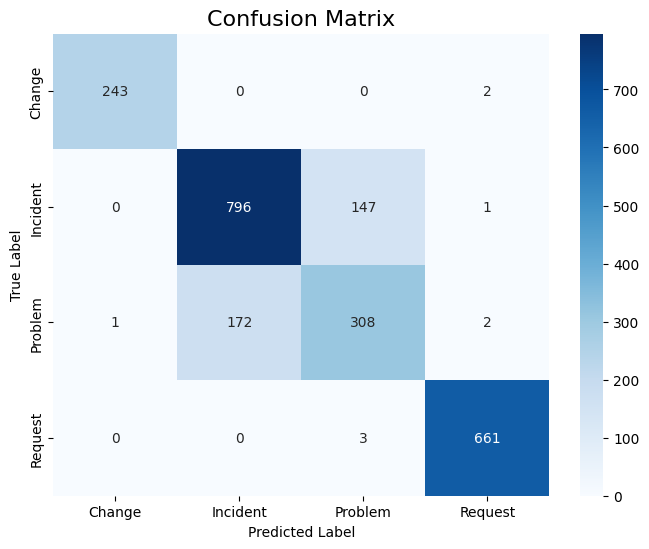

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
labels = label_encoder.classes_

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [53]:
trainer.save_model("final_model")
tokenizer.save_pretrained("final_model")


('final_model/tokenizer_config.json',
 'final_model/special_tokens_map.json',
 'final_model/vocab.txt',
 'final_model/added_tokens.json')

In [55]:
import json

label_map = {
    0: "Change",
    1: "Incident",
    2: "Problem",
    3: "Request"
}

with open("label_map.json", "w") as f:
    json.dump(label_map, f)

from google.colab import files
files.download("label_map.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
from google.colab import drive
drive.mount('/content/drive')

model.save_pretrained("/content/drive/MyDrive/final_model")
tokenizer.save_pretrained("/content/drive/MyDrive/final_model")


Mounted at /content/drive


('/content/drive/MyDrive/final_model/tokenizer_config.json',
 '/content/drive/MyDrive/final_model/special_tokens_map.json',
 '/content/drive/MyDrive/final_model/vocab.txt',
 '/content/drive/MyDrive/final_model/added_tokens.json')